In [1]:
import pandas as pd # type: ignore
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import matplotlib.patches as mpatches # type: ignore
from pathlib import Path

In [2]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
# Auto-detects logs folder relative to this notebook's location.
# Works both locally and on the server as long as the notebook is in the repo root.
LOG_DIR = Path(__file__).parent / "logs" if "__file__" in dir() else Path("logs")
TARGET_LATENCY_S = 1.2   # red dashed line (seconds)
PERCENTILES = [50, 90, 95, 99]
# ─────────────────────────────────────────────────────────────────────────────

In [3]:
def load_latencies(mode: str, v) -> np.ndarray:
    """Read total_latency column from a mode's CSV and return in seconds."""
    path = LOG_DIR / f"{mode}_latency_log.csv"
    if not path.exists():
        print(f"[WARN] {path} not found — skipping {mode}")
        return None
    df = pd.read_csv(path)
    return df["total_latency"].dropna().values / 1000.0 + v

def get_percentiles(latencies: np.ndarray) -> list:
    if latencies is None or len(latencies) == 0:
        return [np.nan] * len(PERCENTILES)
    return [np.percentile(latencies, p) for p in PERCENTILES]

In [4]:
# Load all modes
modes = [
    "safetail",
    "minload_1", "minload_2", "minload_3",
    "minprop_1", "minprop_2", "minprop_3",
    "rand_1",    "rand_2",    "rand_3",
]

raw = {mode: load_latencies(mode, v = 0.005) if mode in ["minprop_1", "minprop_2", "minprop_3"] else load_latencies(mode, 0) for mode in modes}

# Truncate all to the minimum number of entries among available CSVs
available = {m: v for m, v in raw.items() if v is not None}
min_count = min(len(v) for v in available.values())
print(f"Entry counts per mode: { {m: len(v) for m, v in available.items()} }")
print(f"Truncating all to {min_count} entries for fair comparison.\n")

truncated = {m: v[:min_count] for m, v in available.items()}

# Compute percentiles
data = {mode: get_percentiles(truncated.get(mode)) for mode in modes}

# Print summary table
labels = [f"{p}%tile" for p in PERCENTILES]
df_summary = pd.DataFrame(
    {m: data[m] for m in modes if not all(np.isnan(data[m]))},
    index=labels
)
print(df_summary.round(4).to_string())

Entry counts per mode: {'safetail': 3690, 'minload_1': 15015, 'minload_2': 15095, 'minload_3': 15035, 'minprop_1': 14723, 'minprop_2': 14843, 'minprop_3': 14991, 'rand_1': 15003, 'rand_2': 15083, 'rand_3': 14865}
Truncating all to 3690 entries for fair comparison.

         safetail  minload_1  minload_2  minload_3  minprop_1  minprop_2  minprop_3  rand_1  rand_2  rand_3
50%tile    0.0301     0.0521     0.0414     0.0320     0.0354     0.0349     0.0349  0.0647  0.0444  0.0365
90%tile    0.0477     0.1207     0.0816     0.0501     0.0529     0.0515     0.0517  0.1238  0.0894  0.0578
95%tile    0.0496     0.1380     0.0993     0.0538     0.0557     0.0537     0.0540  0.1387  0.1032  0.0730
99%tile    0.0530     0.1647     0.1272     0.0799     0.0686     0.0578     0.0589  0.1642  0.1233  0.0995


In [7]:
def plot_comparison(ax, group_modes, group_labels, colors, hatches, title):
    n_groups = len(PERCENTILES)
    n_bars   = len(group_modes)
    bar_w    = 0.15
    x        = np.arange(n_groups)

    for i, (mode, label, color, hatch) in enumerate(zip(group_modes, group_labels, colors, hatches)):
        vals = data[mode]
        offset = (i - n_bars / 2 + 0.5) * bar_w
        ax.bar(x + offset, vals, width=bar_w,
               label=label, color=color, hatch=hatch, edgecolor="black", linewidth=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{p}%tile" for p in PERCENTILES])
    ax.set_xlabel("Percentile")
    ax.set_ylabel("Total latency (s)")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_ylim(bottom=0)

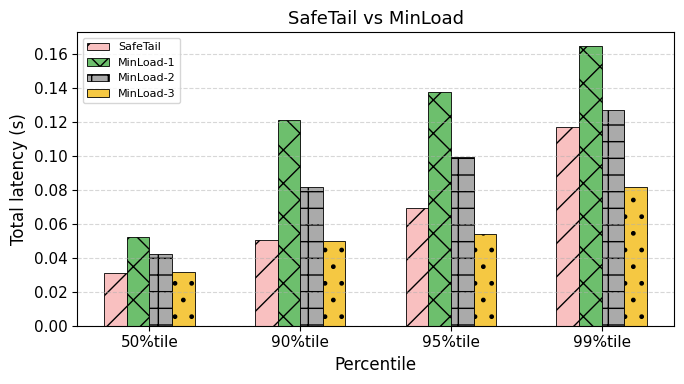

In [43]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_comparison(
    ax,
    group_modes  = ["safetail", "minload_1", "minload_2", "minload_3"],
    group_labels = ["SafeTail", "MinLoad-1", "MinLoad-2", "MinLoad-3"],
    colors       = ["#f9c0c0", "#6dbf6d", "#aaaaaa", "#f5c842"],
    hatches      = ["/", "x", "+", "."],
    title        = "SafeTail vs MinLoad"
)
plt.tight_layout()
plt.show()

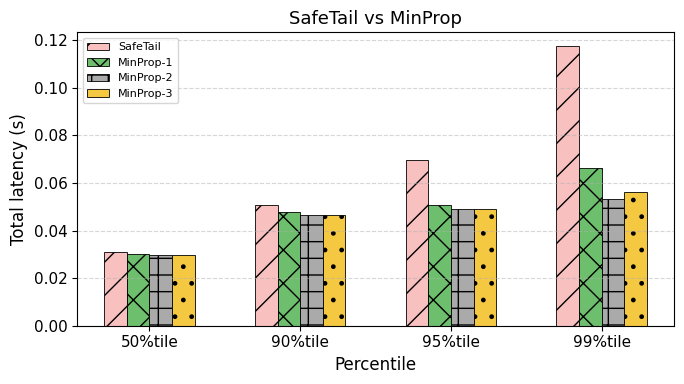

In [44]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_comparison(
    ax,
    group_modes  = ["safetail", "minprop_1", "minprop_2", "minprop_3"],
    group_labels = ["SafeTail", "MinProp-1", "MinProp-2", "MinProp-3"],
    colors       = ["#f9c0c0", "#6dbf6d", "#aaaaaa", "#f5c842"],
    hatches      = ["/", "x", "+", "."],
    title        = "SafeTail vs MinProp"
)
plt.tight_layout()
plt.show()

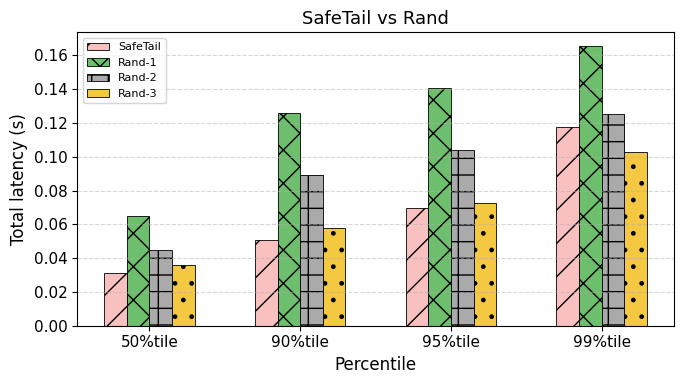

In [45]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_comparison(
    ax,
    group_modes  = ["safetail", "rand_1", "rand_2", "rand_3"],
    group_labels = ["SafeTail", "Rand-1", "Rand-2", "Rand-3"],
    colors       = ["#f9c0c0", "#6dbf6d", "#aaaaaa", "#f5c842"],
    hatches      = ["/", "x", "+", "."],
    title        = "SafeTail vs Rand"
)
plt.tight_layout()
plt.show()

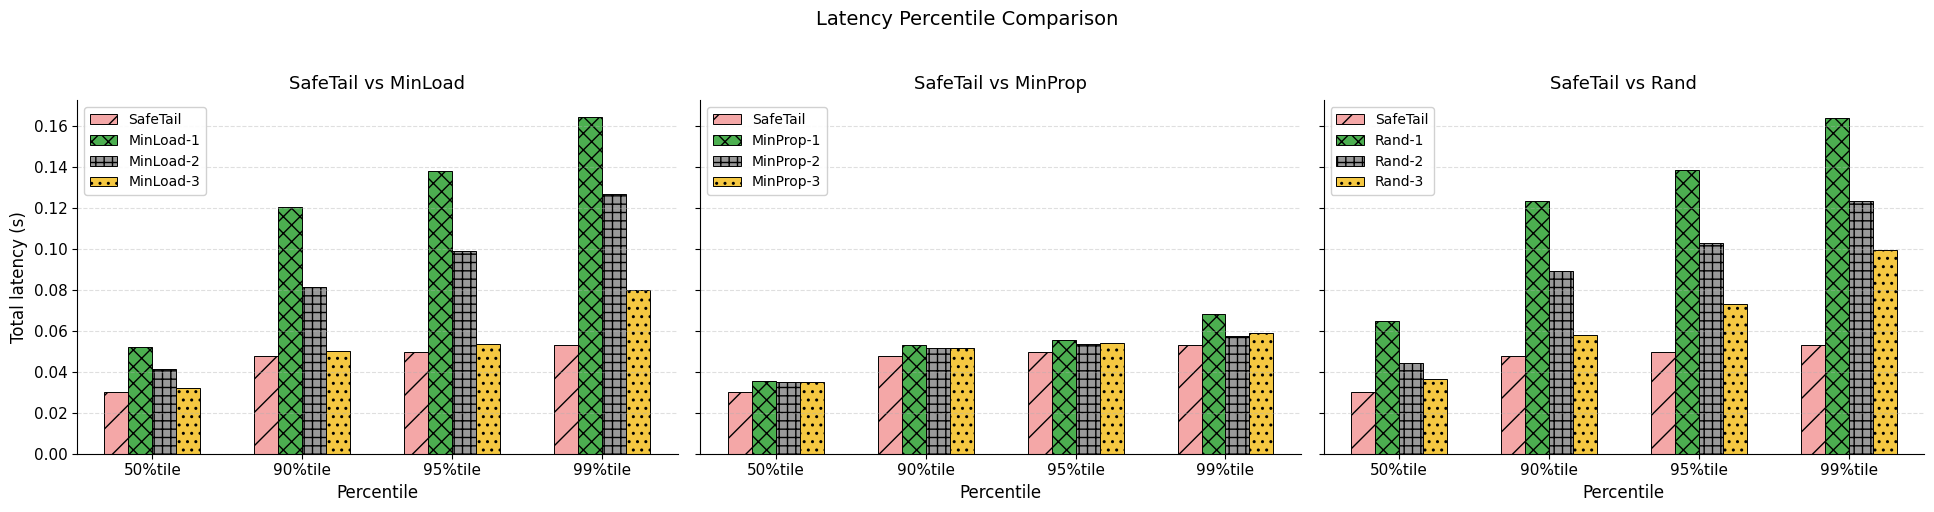

In [5]:
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

STYLE = {
    #            color       hatch
    "safetail":  ("#f4a7a7", "/"),
    "minload_1": ("#4caf50", "xx"),
    "minload_2": ("#999999", "++"),
    "minload_3": ("#f5c842", ".."),
    "minprop_1": ("#4caf50", "xx"),
    "minprop_2": ("#999999", "++"),
    "minprop_3": ("#f5c842", ".."),
    "rand_1":    ("#4caf50", "xx"),
    "rand_2":    ("#999999", "++"),
    "rand_3":    ("#f5c842", ".."),
}

def plot_panel(ax, group_modes, group_labels, title, ylabel=True):
    n_groups = len(PERCENTILES)
    n_bars   = len(group_modes)
    bar_w    = 0.16
    x        = np.arange(n_groups)

    for i, (mode, label) in enumerate(zip(group_modes, group_labels)):
        vals   = data[mode]
        color, hatch = STYLE[mode]
        offset = (i - n_bars / 2 + 0.5) * bar_w
        ax.bar(x + offset, vals, width=bar_w,
               label=label, color=color, hatch=hatch,
               edgecolor="black", linewidth=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{p}%tile" for p in PERCENTILES])
    ax.set_xlabel("Percentile")
    if ylabel:
        ax.set_ylabel("Total latency (s)")
    ax.set_title(title, pad=8)
    ax.legend(loc="upper left", framealpha=0.9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_ylim(bottom=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ── Side-by-side: MinLoad | MinProp ──────────────────────────────────────────
available_modes = [m for m in modes if not all(np.isnan(data[m]))]

panels = []
if any(m in available_modes for m in ["minload_1","minload_2","minload_3"]):
    panels.append(("SafeTail vs MinLoad",
                   ["safetail","minload_1","minload_2","minload_3"],
                   ["SafeTail","MinLoad-1","MinLoad-2","MinLoad-3"]))
if any(m in available_modes for m in ["minprop_1","minprop_2","minprop_3"]):
    panels.append(("SafeTail vs MinProp",
                   ["safetail","minprop_1","minprop_2","minprop_3"],
                   ["SafeTail","MinProp-1","MinProp-2","MinProp-3"]))
if any(m in available_modes for m in ["rand_1","rand_2","rand_3"]):
    panels.append(("SafeTail vs Rand",
                   ["safetail","rand_1","rand_2","rand_3"],
                   ["SafeTail","Rand-1","Rand-2","Rand-3"]))

n_panels = len(panels)
fig, axes = plt.subplots(1, n_panels, figsize=(6.5 * n_panels, 5), sharey=True)
if n_panels == 1:
    axes = [axes]

for idx, (ax, (title, grp_modes, grp_labels)) in enumerate(zip(axes, panels)):
    # filter out modes with no data
    valid = [(m, l) for m, l in zip(grp_modes, grp_labels) if not all(np.isnan(data[m]))]
    plot_panel(ax, [m for m,_ in valid], [l for _,l in valid], title, ylabel=(idx == 0))

plt.suptitle("Latency Percentile Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()